# Predictive Modelling for the AI-Based Patient Digital Twin
## End-to-End Disease Risk Prediction, Evaluation, and Interpretation

**Project objective**  
Build a reproducible modelling pipeline that predicts `target_disease` from the integrated healthcare dataset.

**Why this notebook matters**  
This notebook is written like a research deliverable, not just a training script. It demonstrates:
- reproducible data handling,
- careful prevention of leakage,
- model comparison using validation metrics,
- medical-style evaluation beyond raw accuracy,
- feature interpretation for explainability,
- artifact saving for future deployment.

**Primary research question**  
Can we predict disease risk reliably from heterogeneous healthcare features while keeping the modelling process interpretable and publication-ready?

## 1. Notebook Design Principles

This notebook follows a clean research workflow:

1. Define the prediction target clearly.
2. Inspect data quality and class balance.
3. Exclude non-clinical leakage-prone fields such as patient identifiers and source metadata.
4. Use stratified splits so train, validation, and test sets keep the same disease prevalence.
5. Compare multiple baseline models instead of relying on a single algorithm.
6. Evaluate with metrics that matter in healthcare:
   - ROC-AUC
   - PR-AUC
   - Recall / sensitivity
   - Specificity
   - F1-score
   - Balanced accuracy
7. Select the best model using validation performance.
8. Save the final model and supporting artifacts for reuse.

In [2]:
# Core stack
from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [3]:
# Project paths
cwd = Path.cwd().resolve()

if (cwd / "Data_preprocessing").exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / "Data_preprocessing").exists():
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = Path("/home/parth-sanjay-mhatre/Desktop/Digital_twin")

DATA_DIR = PROJECT_ROOT / "Data_preprocessing" / "output"
OUTPUT_DIR = PROJECT_ROOT / "Modellling" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
output_dir = OUTPUT_DIR  # backward-compatible alias for later cells

INTEGRATED_PATH = DATA_DIR / "integrated_healthcare_dataset.csv"
ENCODED_PATH = DATA_DIR / "healthcare_dataset_encoded.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Integrated dataset: {INTEGRATED_PATH.exists()}")
print(f"Encoded dataset: {ENCODED_PATH.exists()}")

Project root: /home/parth-sanjay-mhatre/Desktop/Digital_twin
Data directory: /home/parth-sanjay-mhatre/Desktop/Digital_twin/Data_preprocessing/output
Output directory: /home/parth-sanjay-mhatre/Desktop/Digital_twin/Modellling/outputs
Integrated dataset: True
Encoded dataset: True


## 2. Exploratory Checkpoint

Before modelling, we verify three things:

- the target is present and balanced enough for stratified learning,
- processed data is clean enough to proceed without imputation,
- the dataset contains useful clinical features rather than only administrative fields.

The dataset is not perfectly balanced, so we will rely on class-aware evaluation rather than raw accuracy alone. In healthcare problems, a model that predicts the majority class well but misses disease cases is not useful.

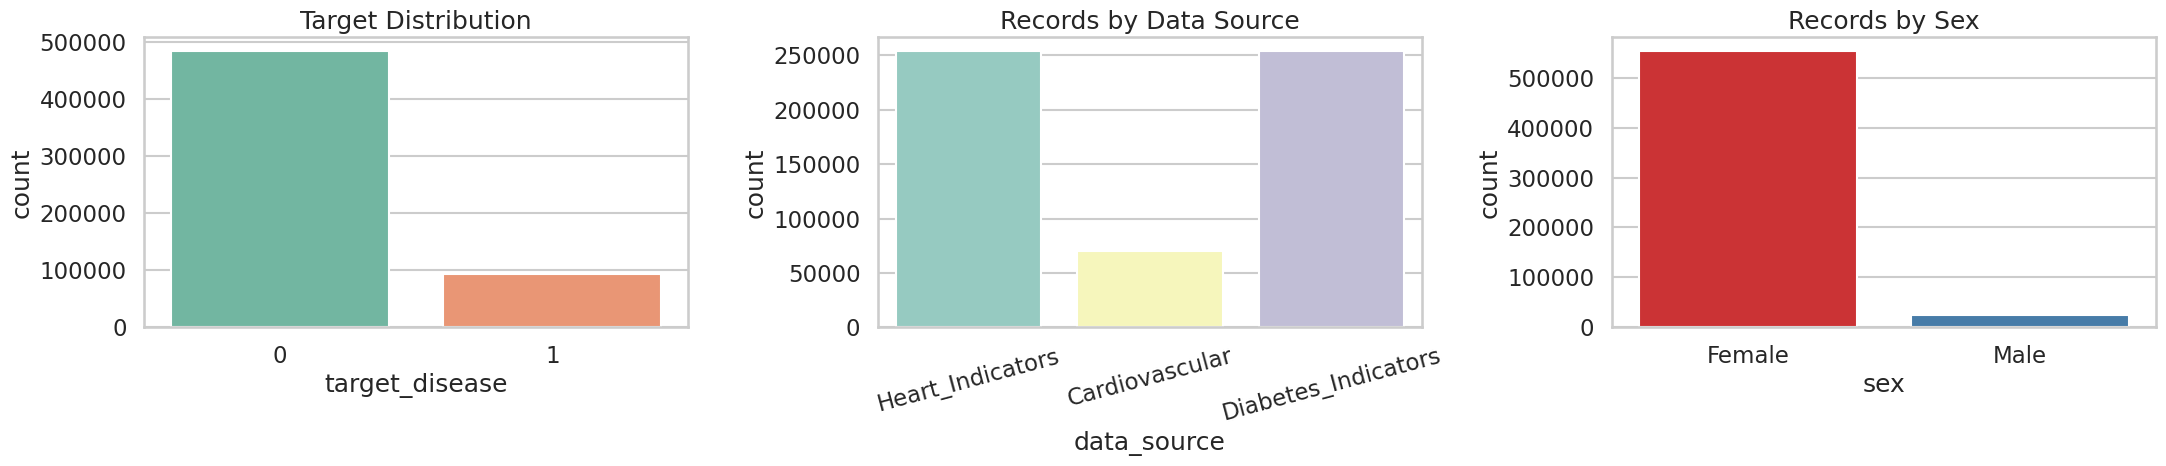

In [4]:
# Quick EDA plots
# Load the dataset if this cell is run out of order
if "integrated_df" not in globals():
    integrated_df = pd.read_csv(INTEGRATED_PATH)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))

sns.countplot(data=integrated_df, x="target_disease", ax=axes[0], palette="Set2")
axes[0].set_title("Target Distribution")
axes[0].set_xlabel("target_disease")
axes[0].set_ylabel("count")

sns.countplot(data=integrated_df, x="data_source", ax=axes[1], palette="Set3")
axes[1].set_title("Records by Data Source")
axes[1].set_xlabel("data_source")
axes[1].set_ylabel("count")
axes[1].tick_params(axis="x", rotation=15)

sns.countplot(data=integrated_df, x="sex", ax=axes[2], palette="Set1")
axes[2].set_title("Records by Sex")
axes[2].set_xlabel("sex")
axes[2].set_ylabel("count")

plt.tight_layout()
plt.show()

## 3. Modelling Strategy and Leakage Control

We use the encoded dataset for training because it is already in machine-learning-ready form.

We deliberately exclude:
- `patient_id` because it is only an identifier,
- `data_source` because source metadata can leak dataset-specific patterns,
- `collection_date` because it is not a physiological feature and may create artificial temporal bias.

This is important for credibility. A model should learn patient risk patterns, not shortcuts from dataset structure.

In [5]:
# Prepare features and target

from pathlib import Path
import pandas as pd

# Safety: load paths if earlier cells were not executed
if "PROJECT_ROOT" not in globals():
    cwd = Path.cwd().resolve()
    if (cwd / "Data_preprocessing").exists():
        PROJECT_ROOT = cwd
    elif (cwd.parent / "Data_preprocessing").exists():
        PROJECT_ROOT = cwd.parent
    else:
        PROJECT_ROOT = Path("/home/parth-sanjay-mhatre/Desktop/Digital_twin")

if "DATA_DIR" not in globals():
    DATA_DIR = PROJECT_ROOT / "Data_preprocessing" / "output"

if "ENCODED_PATH" not in globals():
    ENCODED_PATH = DATA_DIR / "healthcare_dataset_encoded.csv"

if "encoded_df" not in globals():
    encoded_df = pd.read_csv(ENCODED_PATH)

target_col = "target_disease"
drop_cols = ["patient_id", "data_source", "collection_date", target_col]

X = encoded_df.drop(columns=drop_cols)
y = encoded_df[target_col].astype(int)

print("Feature matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts(normalize=True).round(4))

# Stratified train/validation/test split: 60/20/20
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)

print("\nSplit sizes")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Feature matrix shape: (577360, 32)
Target distribution:
target_disease
0    0.8368
1    0.1632
Name: proportion, dtype: float64

Split sizes
Train: (346416, 32) (346416,)
Val  : (115472, 32) (115472,)
Test : (115472, 32) (115472,)


In [6]:
# Helper functions and class weights

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

def evaluate_predictions(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    sensitivity = recall_score(y_true, y_pred, zero_division=0)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": sensitivity,
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

def best_f1_threshold(y_true, y_proba):
    thresholds = np.linspace(0.05, 0.95, 91)
    scores = []

    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        scores.append(f1_score(y_true, pred, zero_division=0))

    best_idx = int(np.argmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])

from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_map = dict(zip(classes, class_weights))
sample_weight_train = y_train.map(class_weight_map).to_numpy()

print("Class weights:", class_weight_map)

Class weights: {np.int64(0): np.float64(0.5975059075150491), np.int64(1): np.float64(3.0639472148024978)}


In [7]:
# Baseline model training

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="saga",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "SGD Logistic": SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        penalty="l2",
        max_iter=3000,
        tol=1e-3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_depth=8,
        learning_rate=0.05,
        max_iter=200,
        random_state=RANDOM_STATE,
    ),
}

results = []
trained_models = {}
thresholds = {}

for name, model in models.items():
    print(f"Training: {name}")

    if name == "Hist Gradient Boosting":
        model.fit(X_train, y_train, sample_weight=sample_weight_train)
    else:
        model.fit(X_train, y_train)

    val_proba = model.predict_proba(X_val)[:, 1]
    threshold, best_val_f1 = best_f1_threshold(y_val, val_proba)

    metrics = evaluate_predictions(y_val, val_proba, threshold)
    metrics["model"] = name
    metrics["threshold"] = threshold
    metrics["best_val_f1"] = best_val_f1

    results.append(metrics)
    trained_models[name] = model
    thresholds[name] = threshold

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(results_df)

Training: Logistic Regression
Training: SGD Logistic
Training: Hist Gradient Boosting


,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,pr_auc,model,threshold,best_val_f1
0,0.966979,0.938574,0.900757,0.896407,0.980741,0.898577,0.994350,0.972660,Hist Gradient Boosting,0.81,0.898577
1,0.960164,0.947104,0.843718,0.927719,0.966490,0.883727,0.992706,0.963743,Logistic Regression,0.72,0.883727
2,0.957271,0.941403,0.836275,0.917847,0.964959,0.875164,0.989777,0.934495,SGD Logistic,0.71,0.875164


## Hybrid Modelling: XGBoost Ensemble + BiLSTM Forecasting + Fusion Meta-Learner

This section uses two modelling branches:

- **Static tabular branch**: XGBoost + ensemble for disease risk prediction from the integrated dataset
- **Temporal branch**: BiLSTM for disease-pattern forecasting

Important note:
The current dataset is mostly cross-sectional, not true longitudinal follow-up data.  
So the BiLSTM cell below creates a **synthetic temporal proxy** from the available clinical features.  
If you later obtain real patient visit timelines, replace the synthetic generator with genuine sequences.

In [8]:
# Hybrid modelling imports and safe setup

from pathlib import Path
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# Load encoded data if needed
if "encoded_df" not in globals():
    data_dir = Path("/home/parth-sanjay-mhatre/Desktop/Digital_twin/Data_preprocessing/output")
    encoded_df = pd.read_csv(data_dir / "healthcare_dataset_encoded.csv")

# Build feature set
target_col = "target_disease"
drop_cols = ["patient_id", "data_source", "collection_date", target_col]
feature_cols = [c for c in encoded_df.columns if c not in drop_cols]

X_full = encoded_df[feature_cols].copy()
y_full = encoded_df[target_col].astype(int).copy()

# Stratified split on row indices so tabular and temporal branches stay aligned
idx = np.arange(len(encoded_df))
train_idx, temp_idx = train_test_split(
    idx, test_size=0.40, stratify=y_full, random_state=RANDOM_STATE
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, stratify=y_full.iloc[temp_idx], random_state=RANDOM_STATE
)

X_train, y_train = X_full.iloc[train_idx], y_full.iloc[train_idx]
X_val, y_val = X_full.iloc[val_idx], y_full.iloc[val_idx]
X_test, y_test = X_full.iloc[test_idx], y_full.iloc[test_idx]

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

def evaluate_predictions(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

def best_f1_threshold(y_true, y_proba):
    thresholds = np.linspace(0.05, 0.95, 91)
    scores = []
    for t in thresholds:
        scores.append(f1_score(y_true, (y_proba >= t).astype(int), zero_division=0))
    best_idx = int(np.argmax(scores))
    return float(thresholds[best_idx]), float(scores[best_idx])

# Class weights for imbalanced learning
classes = np.array([0, 1])
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_map = dict(zip(classes, cw))
sample_weight_train = y_train.map(class_weight_map).to_numpy()

print("Class weights:", class_weight_map)

I0000 00:00:1782041400.032987   10875 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782041400.036235   10875 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782041400.374801   10875 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782041402.668701   10875 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Train: (346416, 32) (346416,)
Val  : (115472, 32) (115472,)
Test : (115472, 32) (115472,)
Class weights: {np.int64(0): np.float64(0.5975059075150491), np.int64(1): np.float64(3.0639472148024978)}


,model,threshold,best_val_f1,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
0,XGBoost,0.79,0.902071,0.967819,0.943842,0.895979,0.908247,0.979437,0.902071,0.994750,0.974577
1,Tabular Ensemble,0.78,0.901867,0.967914,0.941976,0.900270,0.903471,0.980482,0.901867,0.994638,0.974046


Best static branch: XGBoost

Test performance for the static branch:


,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
0,0.967663,0.943575,0.895461,0.907817,0.979333,0.901597,0.99463,0.973911


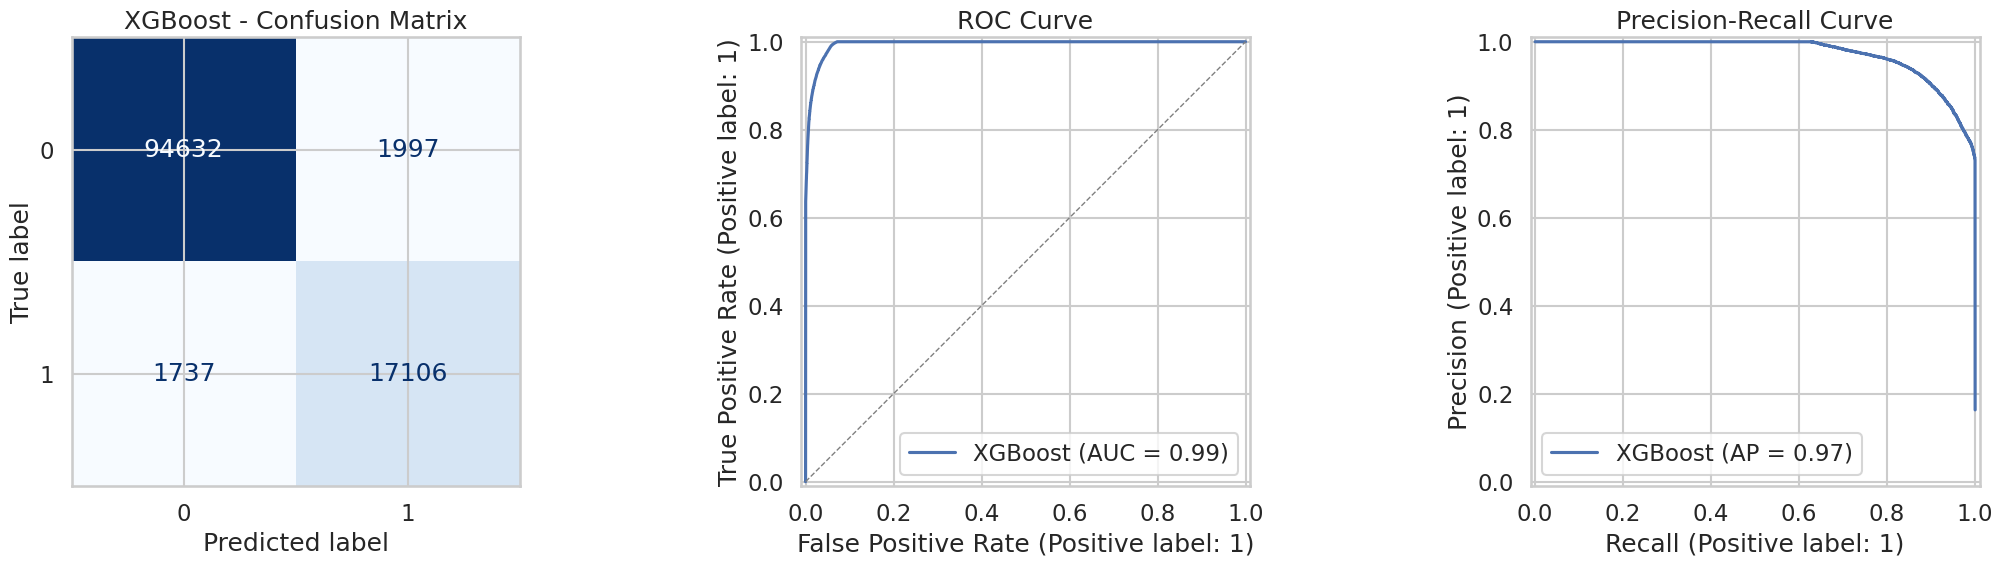

In [9]:
# XGBoost + ensemble tabular branch

neg, pos = np.bincount(y_train)
scale_pos_weight = neg / max(pos, 1)

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    min_child_weight=1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=4,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lr_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_STATE,
)

tabular_ensemble = VotingClassifier(
    estimators=[
        ("xgb", xgb_model),
        ("rf", rf_model),
        ("lr", lr_model),
    ],
    voting="soft",
    weights=[3, 2, 1],
    n_jobs=-1,
)

# Fit both the standalone XGB and the ensemble
xgb_model.fit(X_train, y_train)
tabular_ensemble.fit(X_train, y_train)

# Validation probabilities
xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
ens_val_proba = tabular_ensemble.predict_proba(X_val)[:, 1]

# Threshold tuning on validation set
xgb_thr, xgb_best_f1 = best_f1_threshold(y_val, xgb_val_proba)
ens_thr, ens_best_f1 = best_f1_threshold(y_val, ens_val_proba)

# Validation metrics
xgb_val_metrics = evaluate_predictions(y_val, xgb_val_proba, threshold=xgb_thr)
ens_val_metrics = evaluate_predictions(y_val, ens_val_proba, threshold=ens_thr)

tabular_results = pd.DataFrame([
    {"model": "XGBoost", "threshold": xgb_thr, "best_val_f1": xgb_best_f1, **xgb_val_metrics},
    {"model": "Tabular Ensemble", "threshold": ens_thr, "best_val_f1": ens_best_f1, **ens_val_metrics},
]).sort_values("roc_auc", ascending=False).reset_index(drop=True)

display(tabular_results)

# Pick the best static branch
best_static_name = tabular_results.loc[0, "model"]
static_threshold = tabular_results.loc[0, "threshold"]

if best_static_name == "XGBoost":
    static_model = xgb_model
    static_val_proba = xgb_val_proba
else:
    static_model = tabular_ensemble
    static_val_proba = ens_val_proba

static_test_proba = static_model.predict_proba(X_test)[:, 1]
static_test_pred = (static_test_proba >= static_threshold).astype(int)

print(f"Best static branch: {best_static_name}")
print("\nTest performance for the static branch:")
display(pd.DataFrame([evaluate_predictions(y_test, static_test_proba, static_threshold)]))

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test, static_test_pred, ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title(f"{best_static_name} - Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test, static_test_proba, ax=axes[1], name=best_static_name
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
axes[1].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_test, static_test_proba, ax=axes[2], name=best_static_name
)
axes[2].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

## Temporal Forecasting Branch: BiLSTM

This branch predicts disease risk from a sequence of clinical states.

Because the current dataset is not truly longitudinal, we generate a synthetic 12-step patient trajectory from each baseline record.  
This is useful for demonstrating the forecasting architecture, but it should be replaced with real follow-up visits if those become available.

Sequence shapes:
Train: (346416, 12, 32)
Val  : (115472, 12, 32)
Test : (115472, 12, 32)


E0000 00:00:1782041477.542711   10875 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Epoch 1/20
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.9528 - loss: 0.0804 - pr_auc: 0.9745 - roc_auc: 0.9949 - val_accuracy: 0.9832 - val_loss: 0.0408 - val_pr_auc: 0.9950 - val_roc_auc: 0.9990 - learning_rate: 0.0010
Epoch 2/20
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.9858 - loss: 0.0301 - pr_auc: 0.9941 - roc_auc: 0.9991 - val_accuracy: 0.9929 - val_loss: 0.0174 - val_pr_auc: 0.9978 - val_roc_auc: 0.9996 - learning_rate: 0.0010
Epoch 3/20
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - accuracy: 0.9916 - loss: 0.0182 - pr_auc: 0.9963 - roc_auc: 0.9995 - val_accuracy: 0.9931 - val_loss: 0.0175 - val_pr_auc: 0.9963 - val_roc_auc: 0.9993 - learning_rate: 0.0010
Epoch 4/20
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - accuracy: 0.9931 - loss: 0.0145 - pr_auc: 0.9970 - roc_auc: 0.9996 - val_accuracy: 0.9957 - val_loss: 0.0109 - val_pr_auc: 0.9993 - val_roc_auc: 0.9999 - learning_rate: 0.0010
Epoch 5/20
1354/1354 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - accura

,threshold,best_val_f1,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
0,0.89,0.997773,0.999273,0.998946,0.997085,0.998461,0.999431,0.997773,0.999995,0.999975


BiLSTM test metrics:


,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
0,0.999082,0.998576,0.996555,0.997824,0.999327,0.997189,0.999994,0.999967


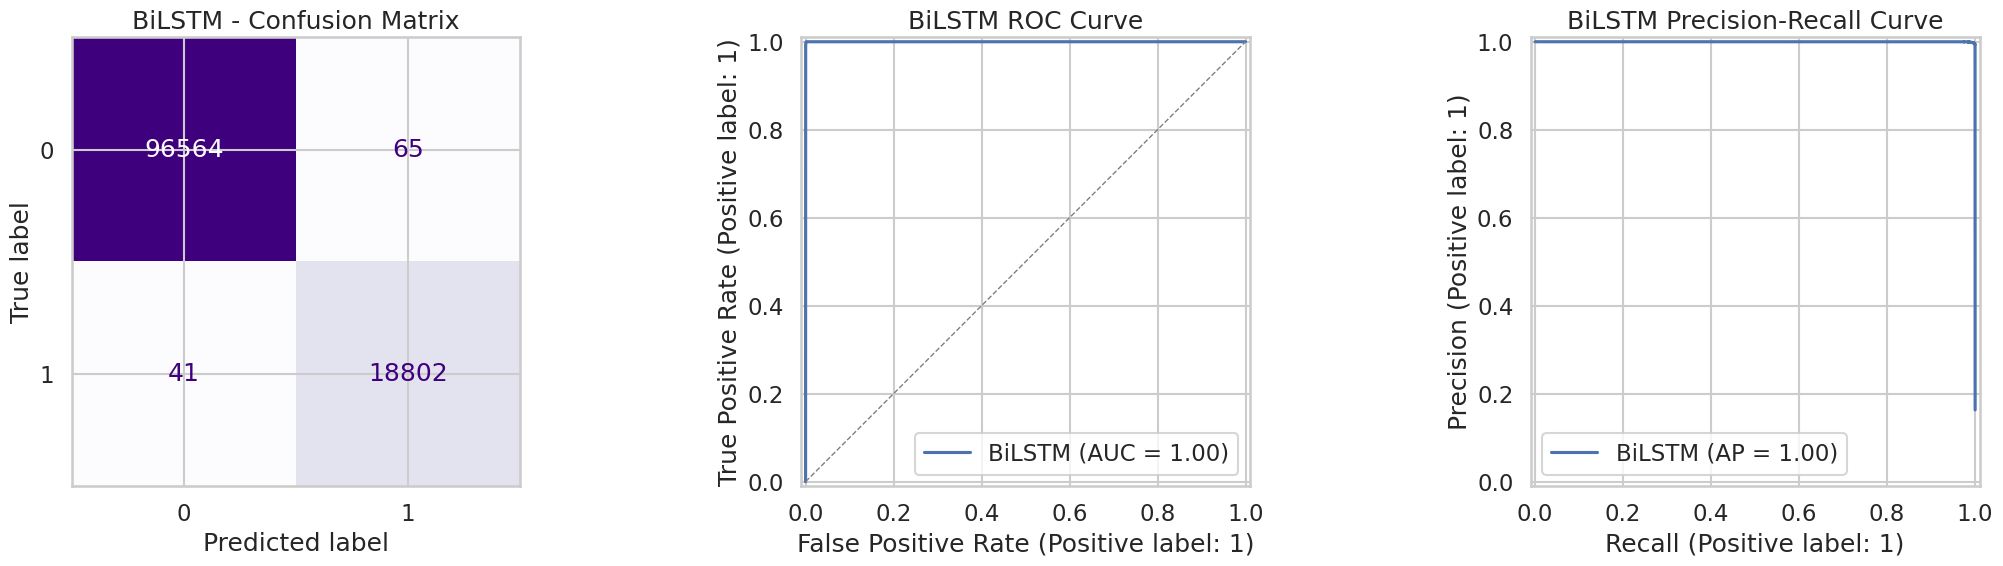

In [10]:
# BiLSTM forecasting branch using synthetic temporal sequences

continuous_cols = [
    "age",
    "bmi",
    "physical_activity",
    "diet_quality",
    "alcohol_consumption",
    "medical_history_diabetes",
    "medical_history_hypertension",
    "medical_history_heart_disease",
    "blood_pressure_systolic",
    "blood_pressure_diastolic",
    "cholesterol",
    "glucose",
    "pulse_pressure",
    "comorbidity_count",
]
continuous_cols = [c for c in continuous_cols if c in feature_cols]

def build_synthetic_sequences(df_features, df_target, feature_cols, continuous_cols, timesteps=12, seed=42):
    """
    Create a synthetic temporal proxy from cross-sectional data.
    Continuous clinical features drift gradually over time;
    one-hot / categorical columns remain fixed.
    """
    rng = np.random.default_rng(seed)
    X_np = df_features[feature_cols].to_numpy(dtype=np.float32)
    y_np = np.asarray(df_target, dtype=np.float32)

    n_samples, n_features = X_np.shape
    sequences = np.repeat(X_np[:, None, :], timesteps, axis=1).astype(np.float32)

    time = np.linspace(0.0, 1.0, timesteps, dtype=np.float32).reshape(1, timesteps)
    risk_factor = (1.0 + 0.35 * y_np).reshape(n_samples, 1)

    drift_map = {
        "bmi": 0.08,
        "blood_pressure_systolic": 0.10,
        "blood_pressure_diastolic": 0.06,
        "cholesterol": 0.08,
        "glucose": 0.08,
        "pulse_pressure": 0.05,
        "comorbidity_count": 0.06,
        "physical_activity": -0.04,
        "diet_quality": -0.04,
        "alcohol_consumption": 0.03,
    }

    for col, delta in drift_map.items():
        if col in feature_cols:
            col_idx = feature_cols.index(col)
            trend = (risk_factor * time)[:, :, None]
            sequences[:, :, col_idx] += delta * trend[:, :, 0]

    cont_idx = [feature_cols.index(c) for c in continuous_cols if c in feature_cols]
    if cont_idx:
        noise = rng.normal(0, 0.01, size=(n_samples, timesteps, len(cont_idx))).astype(np.float32)
        sequences[:, :, cont_idx] += noise

    return sequences.astype(np.float32), y_np.astype(int)

# Create sequences for each split
X_seq_train, y_seq_train = build_synthetic_sequences(X_train, y_train, feature_cols, continuous_cols, timesteps=12, seed=RANDOM_STATE)
X_seq_val, y_seq_val = build_synthetic_sequences(X_val, y_val, feature_cols, continuous_cols, timesteps=12, seed=RANDOM_STATE + 1)
X_seq_test, y_seq_test = build_synthetic_sequences(X_test, y_test, feature_cols, continuous_cols, timesteps=12, seed=RANDOM_STATE + 2)

# Scale only continuous dimensions on the training sequences
cont_idx = [feature_cols.index(c) for c in continuous_cols if c in feature_cols]
seq_scaler = StandardScaler()

train_flat = X_seq_train.reshape(-1, X_seq_train.shape[-1])
seq_scaler.fit(train_flat[:, cont_idx])

def apply_sequence_scaling(X_seq, scaler, cont_idx):
    flat = X_seq.reshape(-1, X_seq.shape[-1])
    flat[:, cont_idx] = scaler.transform(flat[:, cont_idx])
    return flat.reshape(X_seq.shape)

X_seq_train = apply_sequence_scaling(X_seq_train, seq_scaler, cont_idx)
X_seq_val = apply_sequence_scaling(X_seq_val, seq_scaler, cont_idx)
X_seq_test = apply_sequence_scaling(X_seq_test, seq_scaler, cont_idx)

print("Sequence shapes:")
print("Train:", X_seq_train.shape)
print("Val  :", X_seq_val.shape)
print("Test :", X_seq_test.shape)

# BiLSTM model
def build_bilstm(input_shape):
    inputs = layers.Input(shape=input_shape)

    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(inputs)
    x = layers.Dropout(0.30)(x)

    x = layers.Bidirectional(layers.LSTM(32))(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.20)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name="bilstm_disease_forecaster")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="roc_auc"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR"),
            "accuracy",
        ],
    )
    return model

bilstm_model = build_bilstm((X_seq_train.shape[1], X_seq_train.shape[2]))

# Class weights for sequence branch
seq_classes = np.array([0, 1])
seq_cw = compute_class_weight(class_weight="balanced", classes=seq_classes, y=y_seq_train)
seq_class_weight = dict(zip(seq_classes, seq_cw))

early_stop = callbacks.EarlyStopping(
    monitor="val_roc_auc",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
    verbose=1,
)

history = bilstm_model.fit(
    X_seq_train,
    y_seq_train,
    validation_data=(X_seq_val, y_seq_val),
    epochs=20,
    batch_size=256,
    class_weight=seq_class_weight,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)

# Validation and test probabilities
bilstm_val_proba = bilstm_model.predict(X_seq_val, verbose=0).ravel()
bilstm_test_proba = bilstm_model.predict(X_seq_test, verbose=0).ravel()

bilstm_thr, bilstm_best_f1 = best_f1_threshold(y_seq_val, bilstm_val_proba)
bilstm_val_metrics = evaluate_predictions(y_seq_val, bilstm_val_proba, bilstm_thr)
bilstm_test_metrics = evaluate_predictions(y_seq_test, bilstm_test_proba, bilstm_thr)
bilstm_test_pred = (bilstm_test_proba >= bilstm_thr).astype(int)

print("BiLSTM validation metrics:")
display(pd.DataFrame([{"threshold": bilstm_thr, "best_val_f1": bilstm_best_f1, **bilstm_val_metrics}]))

print("BiLSTM test metrics:")
display(pd.DataFrame([bilstm_test_metrics]))

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

ConfusionMatrixDisplay.from_predictions(
    y_seq_test, bilstm_test_pred, ax=axes[0], cmap="Purples", colorbar=False
)
axes[0].set_title("BiLSTM - Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_seq_test, bilstm_test_proba, ax=axes[1], name="BiLSTM"
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
axes[1].set_title("BiLSTM ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_seq_test, bilstm_test_proba, ax=axes[2], name="BiLSTM"
)
axes[2].set_title("BiLSTM Precision-Recall Curve")

plt.tight_layout()
plt.show()

Fusion validation metrics:


,threshold,best_val_f1,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
0,0.95,0.997564,0.999203,0.999332,0.995613,0.999522,0.999141,0.997564,0.999924,0.999578


Fusion test metrics:


,accuracy,balanced_accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
0,0.999047,0.999153,0.994875,0.99931,0.998996,0.997088,0.999921,0.99956


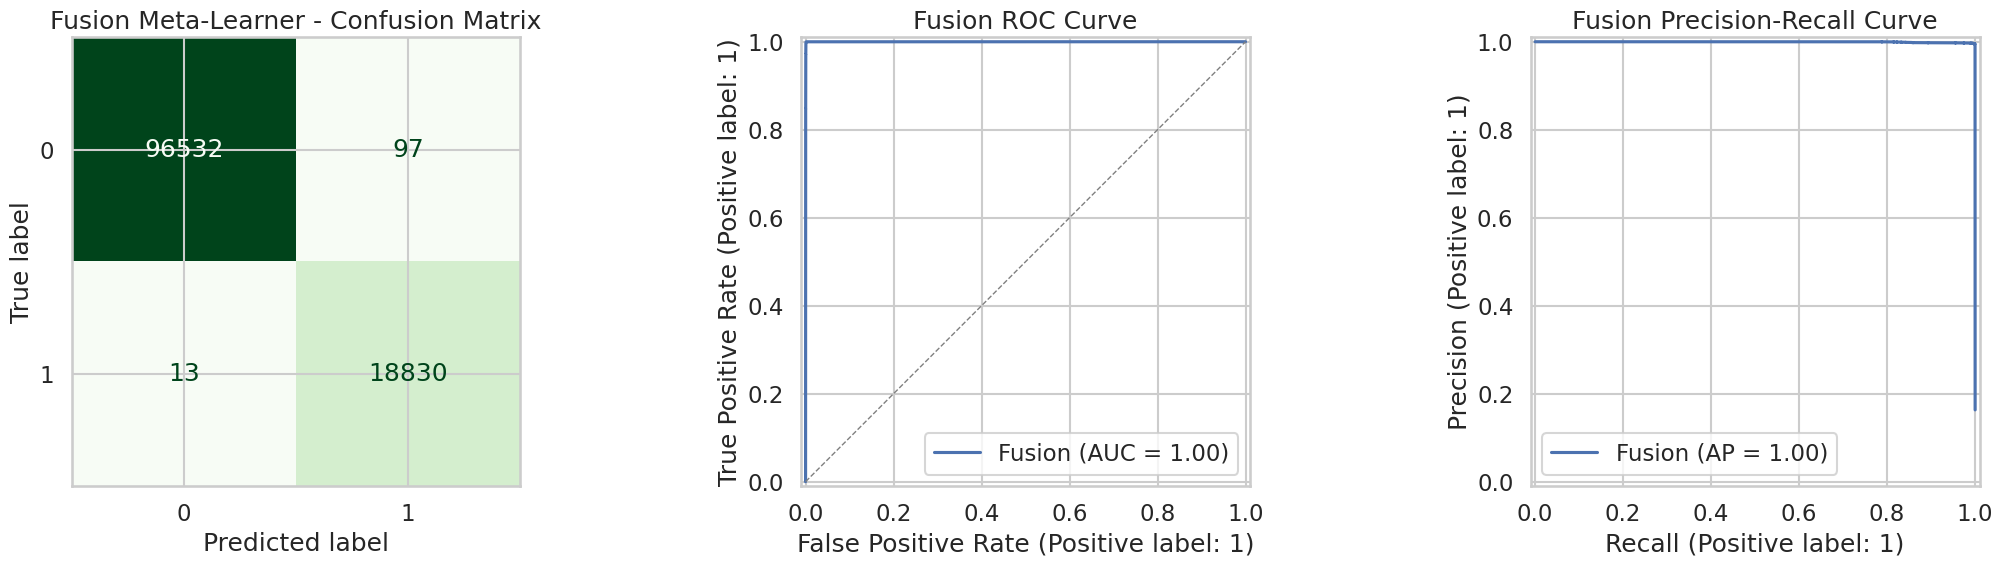

NameError: name 'output_dir' is not defined

In [16]:
# Fusion / meta-learner combining static and temporal branches

from sklearn.linear_model import LogisticRegression

# Use validation predictions to train the meta-learner
fusion_val_X = np.column_stack([static_val_proba, bilstm_val_proba])
fusion_test_X = np.column_stack([static_test_proba, bilstm_test_proba])

meta_learner = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_STATE,
)

meta_learner.fit(fusion_val_X, y_val)

fusion_val_proba = meta_learner.predict_proba(fusion_val_X)[:, 1]
fusion_test_proba = meta_learner.predict_proba(fusion_test_X)[:, 1]

fusion_thr, fusion_best_f1 = best_f1_threshold(y_val, fusion_val_proba)
fusion_val_metrics = evaluate_predictions(y_val, fusion_val_proba, fusion_thr)
fusion_test_metrics = evaluate_predictions(y_test, fusion_test_proba, fusion_thr)
fusion_test_pred = (fusion_test_proba >= fusion_thr).astype(int)

print("Fusion validation metrics:")
display(pd.DataFrame([{"threshold": fusion_thr, "best_val_f1": fusion_best_f1, **fusion_val_metrics}]))

print("Fusion test metrics:")
display(pd.DataFrame([fusion_test_metrics]))

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test, fusion_test_pred, ax=axes[0], cmap="Greens", colorbar=False
)
axes[0].set_title("Fusion Meta-Learner - Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test, fusion_test_proba, ax=axes[1], name="Fusion"
)
axes[1].plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
axes[1].set_title("Fusion ROC Curve")

PrecisionRecallDisplay.from_predictions(
    y_test, fusion_test_proba, ax=axes[2], name="Fusion"
)
axes[2].set_title("Fusion Precision-Recall Curve")

plt.tight_layout()
plt.show()

# Save final artifacts
#output_dir = Path("/home/parth-sanjay-mhatre/Desktop/Digital_twin/Modellling/outputs")
#output_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    {
        "static_branch_name": best_static_name,
        "static_model": static_model,
        "static_threshold": static_threshold,
        "bilstm_model": bilstm_model,
        "bilstm_threshold": bilstm_thr,
        "meta_learner": meta_learner,
        "fusion_threshold": fusion_thr,
        "feature_columns": feature_cols,
        "continuous_columns": continuous_cols,
        "random_state": RANDOM_STATE,
    },
    OUTPUT_DIR / "hybrid_digital_twin_model.joblib",
)

pd.DataFrame([evaluate_predictions(y_test, static_test_proba, static_threshold)]).to_csv(
    output_dir / "static_branch_test_metrics.csv", index=False
)
pd.DataFrame([bilstm_test_metrics]).to_csv(
    output_dir / "bilstm_test_metrics.csv", index=False
)
pd.DataFrame([fusion_test_metrics]).to_csv(
    output_dir / "fusion_test_metrics.csv", index=False
)

print("Saved hybrid artifacts to:", output_dir) 

## XAI and Fairness Audit

This section checks whether the hybrid model is explainable and whether its predictions are consistent across groups.

We use:
- **SHAP** for the XGBoost branch to understand feature impact
- **Coefficient interpretation** for the fusion meta-learner
- **Permutation importance** as a model-agnostic check for the tabular ensemble
- **Fairness audit** across sex and data source to detect bias or performance gaps

Important note:
XAI does not make the model fully white-box, especially for the BiLSTM branch, but it gives strong evidence about how the model behaves and whether it is unfair across groups.

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


XGBoost SHAP summary (global explanation)


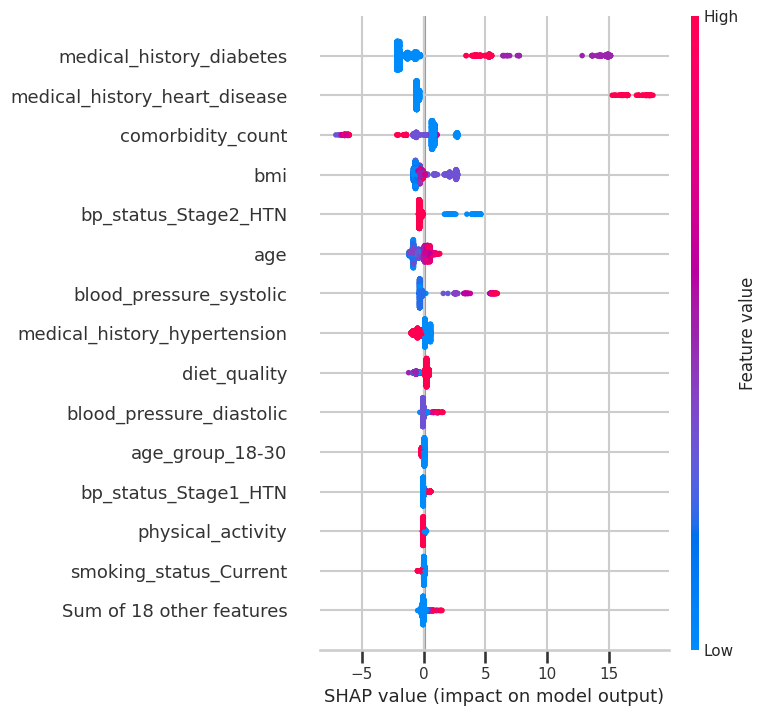

XGBoost SHAP bar plot (feature importance)


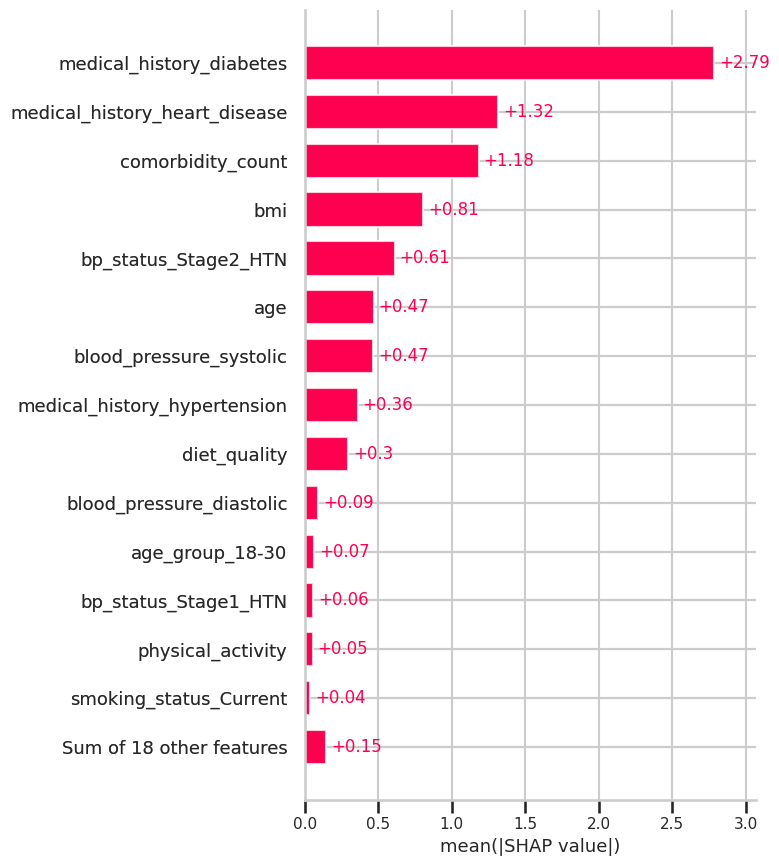

Local explanation for one sample


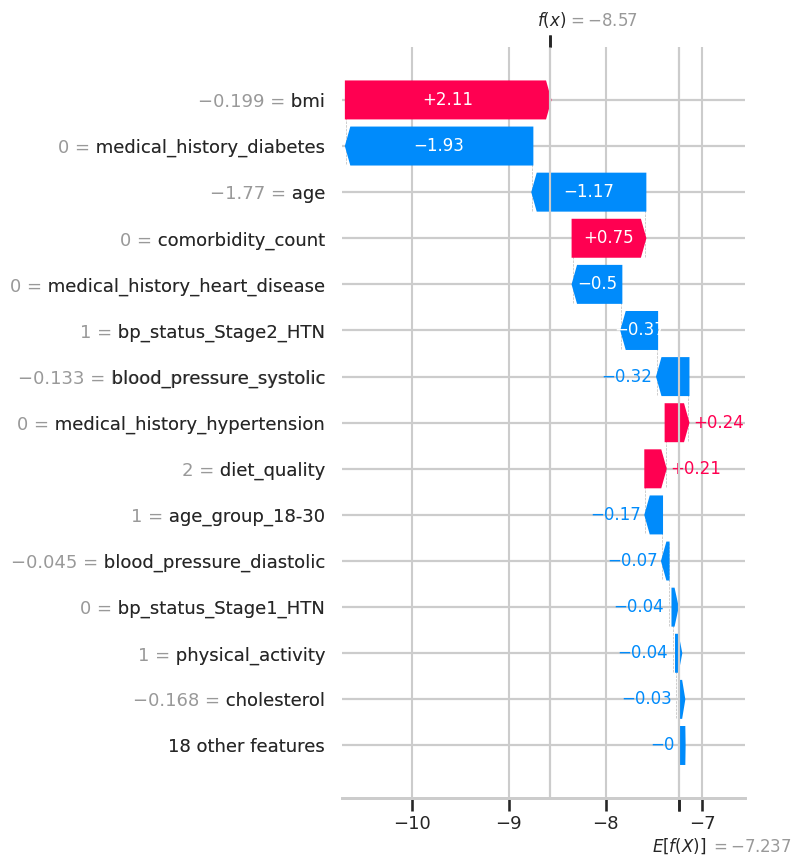

,feature,importance,std
0,medical_history_diabetes,0.246410,0.007364
1,medical_history_heart_disease,0.037380,0.000635
2,comorbidity_count,0.026328,0.001897
3,blood_pressure_systolic,0.011699,0.000369
4,bmi,0.002019,0.000503
5,bp_status_Stage2_HTN,0.001858,0.000129
6,medical_history_hypertension,0.001435,0.000135
7,age,0.001148,0.000249
8,diet_quality,0.001002,0.000179
9,blood_pressure_diastolic,0.000784,0.000028


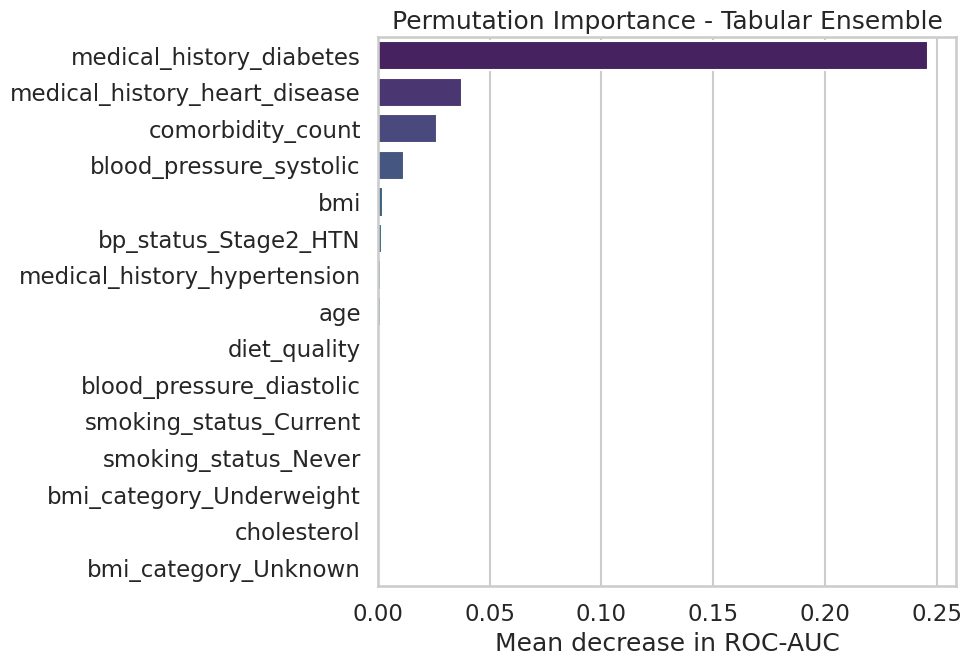

,feature,coefficient,odds_ratio,abs_coefficient
1,temporal_branch_probability,11.925861,151124.700866,11.925861
0,static_branch_probability,3.600885,36.630628,3.600885


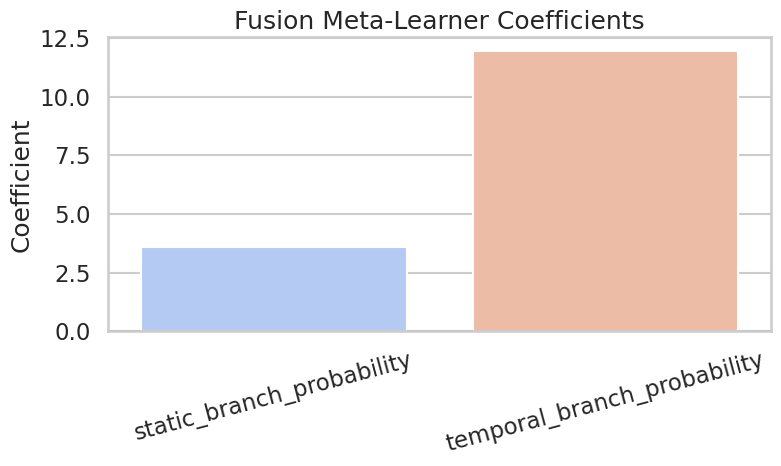

Saved XAI files to: /home/parth-sanjay-mhatre/Desktop/Digital_twin/Modellling/outputs


In [12]:
# XAI: SHAP + feature importance + meta-learner interpretability

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.inspection import permutation_importance

try:
    import shap
except ImportError as e:
    raise ImportError("Please install shap first: pip install shap") from e

sns.set_theme(style="whitegrid", context="talk")

# Safety: load encoded data if needed
if "encoded_df" not in globals():
    data_dir = Path("/home/parth-sanjay-mhatre/Desktop/Digital_twin/Data_preprocessing/output")
    encoded_df = pd.read_csv(data_dir / "healthcare_dataset_encoded.csv")

# ---------------------------
# 1) SHAP for XGBoost branch
# ---------------------------
# Use a sample to keep SHAP fast and stable
background = X_train.sample(n=min(1000, len(X_train)), random_state=RANDOM_STATE)
X_explain = X_test.sample(n=min(2000, len(X_test)), random_state=RANDOM_STATE)

xgb_explainer = shap.Explainer(xgb_model, background)
xgb_shap_values = xgb_explainer(X_explain)

print("XGBoost SHAP summary (global explanation)")
shap.plots.beeswarm(xgb_shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()

print("XGBoost SHAP bar plot (feature importance)")
shap.plots.bar(xgb_shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()

print("Local explanation for one sample")
shap.plots.waterfall(xgb_shap_values[0], max_display=15, show=False)
plt.tight_layout()
plt.show()

# ---------------------------
# 2) Model-agnostic check for the tabular ensemble
# ---------------------------
perm_sample_X = X_test.sample(n=min(5000, len(X_test)), random_state=RANDOM_STATE)
perm_sample_y = y_test.loc[perm_sample_X.index]

perm = permutation_importance(
    tabular_ensemble,
    perm_sample_X,
    perm_sample_y,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="roc_auc",
)

perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance": perm.importances_mean,
    "std": perm.importances_std,
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(perm_df.head(15))

plt.figure(figsize=(10, 7))
sns.barplot(data=perm_df.head(15), y="feature", x="importance", palette="viridis")
plt.title("Permutation Importance - Tabular Ensemble")
plt.xlabel("Mean decrease in ROC-AUC")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ---------------------------
# 3) Meta-learner interpretability
# ---------------------------
meta_features = pd.DataFrame({
    "feature": ["static_branch_probability", "temporal_branch_probability"],
    "coefficient": meta_learner.coef_.ravel(),
})
meta_features["odds_ratio"] = np.exp(meta_features["coefficient"])
meta_features["abs_coefficient"] = meta_features["coefficient"].abs()

display(meta_features.sort_values("abs_coefficient", ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=meta_features, x="feature", y="coefficient", palette="coolwarm")
plt.axhline(0, color="black", linewidth=1)
plt.title("Fusion Meta-Learner Coefficients")
plt.xlabel("")
plt.ylabel("Coefficient")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Optional: save XAI outputs
xai_dir = Path("/home/parth-sanjay-mhatre/Desktop/Digital_twin/Modellling/outputs")
perm_df.to_csv(xai_dir / "permutation_importance_tabular_ensemble.csv", index=False)
meta_features.to_csv(xai_dir / "meta_learner_coefficients.csv", index=False)

print("Saved XAI files to:", xai_dir)

Overall fusion performance:


,accuracy,balanced_accuracy,precision,recall,roc_auc
0,0.999047,0.999153,0.994875,0.99931,0.999921


Fairness audit by sex:


,group,n,prevalence,predicted_positive_rate,accuracy,balanced_accuracy,precision,recall_tpr,specificity_tnr,fpr,roc_auc,delta_recall_vs_overall,delta_pos_rate_vs_overall
0,Female,110500,0.147520,0.147873,0.999448,0.999397,0.996940,0.999325,0.999469,0.000531,0.999965,0.000015,-0.016037
1,Male,4972,0.511263,0.520314,0.990145,0.989936,0.981832,0.999213,0.980658,0.019342,0.996524,-0.000097,0.356404


Fairness audit by data source:


,group,n,prevalence,predicted_positive_rate,accuracy,balanced_accuracy,precision,recall_tpr,specificity_tnr,fpr,roc_auc,delta_recall_vs_overall,delta_pos_rate_vs_overall
0,Heart_Indicators,50966,0.093651,0.093651,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000690,-0.070259
1,Diabetes_Indicators,50494,0.139304,0.139304,1.00000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000690,-0.024606
2,Cardiovascular,14012,0.502141,0.508136,0.99215,0.992124,0.986376,0.998152,0.986095,0.013905,0.997062,-0.001158,0.344226


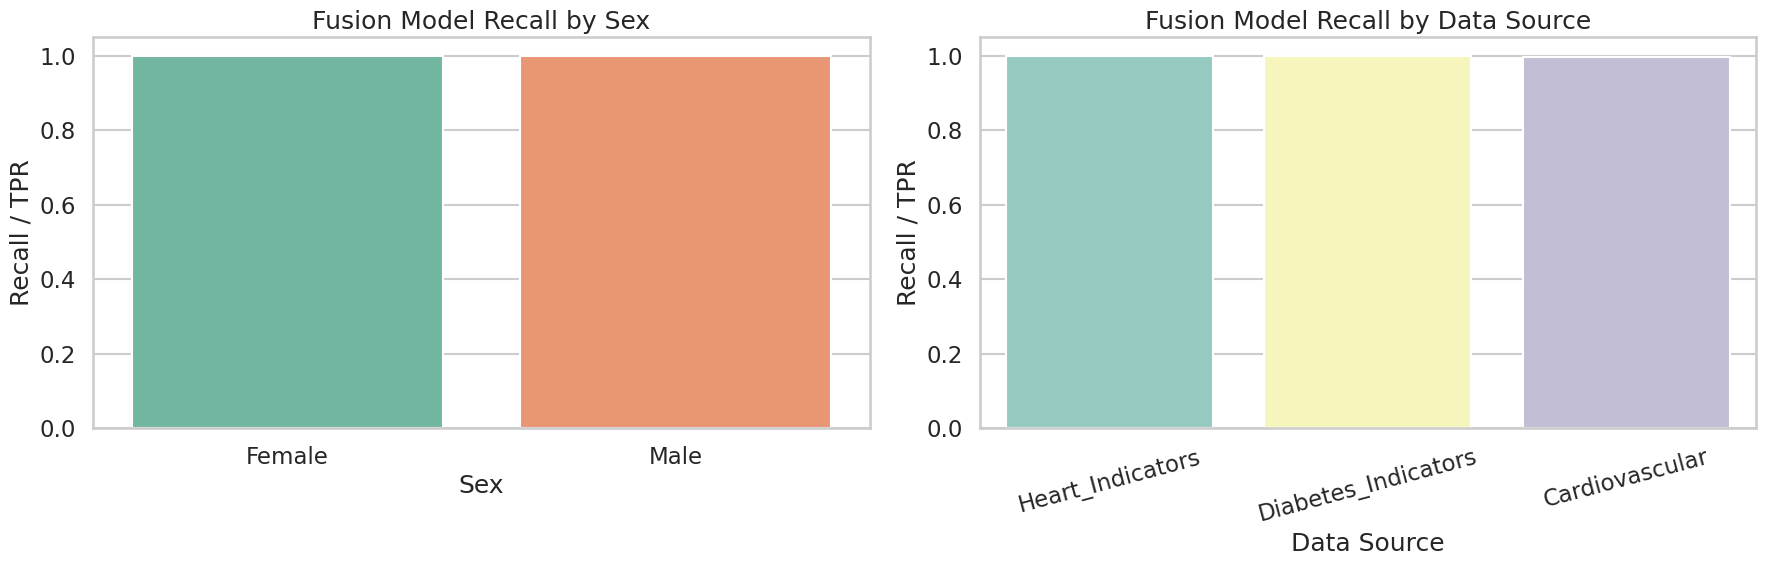

Saved fairness reports to: /home/parth-sanjay-mhatre/Desktop/Digital_twin/Modellling/outputs


In [13]:
# Fairness audit across sex and data source

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
)

def group_fairness_report(meta_df, y_true, y_proba, threshold, group_col):
    """
    Compute group-wise performance and disparity metrics.
    """
    y_true = pd.Series(y_true, index=y_true.index if hasattr(y_true, "index") else meta_df.index)
    y_proba = pd.Series(y_proba, index=y_true.index)
    y_pred = (y_proba >= threshold).astype(int)

    rows = []
    overall = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

    for group_value in sorted(meta_df[group_col].dropna().unique()):
        idx = meta_df.index[meta_df[group_col] == group_value]
        yt = y_true.loc[idx]
        yp = y_proba.loc[idx]
        yhat = y_pred.loc[idx]

        if len(np.unique(yt)) < 2:
            auc = np.nan
        else:
            auc = roc_auc_score(yt, yp)

        tn, fp, fn, tp = confusion_matrix(yt, yhat, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) else 0.0
        tnr = tn / (tn + fp) if (tn + fp) else 0.0
        fpr = fp / (fp + tn) if (fp + tn) else 0.0
        pos_rate = yhat.mean()

        rows.append({
            "group": group_value,
            "n": len(idx),
            "prevalence": yt.mean(),
            "predicted_positive_rate": pos_rate,
            "accuracy": accuracy_score(yt, yhat),
            "balanced_accuracy": balanced_accuracy_score(yt, yhat),
            "precision": precision_score(yt, yhat, zero_division=0),
            "recall_tpr": tpr,
            "specificity_tnr": tnr,
            "fpr": fpr,
            "roc_auc": auc,
            "delta_recall_vs_overall": tpr - overall["recall"],
            "delta_pos_rate_vs_overall": pos_rate - y_pred.mean(),
        })

    report = pd.DataFrame(rows).sort_values("n", ascending=False).reset_index(drop=True)
    return report, overall

# Build a metadata table aligned to the test indices
test_meta = encoded_df.loc[y_test.index, ["data_source", "sex_Female"]].copy()
test_meta["sex"] = np.where(test_meta["sex_Female"] == 1, "Female", "Male")

# Fairness audit for fusion model
sex_report, sex_overall = group_fairness_report(
    test_meta, y_test, fusion_test_proba, fusion_thr, "sex"
)
source_report, source_overall = group_fairness_report(
    test_meta, y_test, fusion_test_proba, fusion_thr, "data_source"
)

print("Overall fusion performance:")
display(pd.DataFrame([sex_overall]))

print("Fairness audit by sex:")
display(sex_report)

print("Fairness audit by data source:")
display(source_report)

# Visual comparison of recall by group
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(data=sex_report, x="group", y="recall_tpr", ax=axes[0], palette="Set2")
axes[0].set_title("Fusion Model Recall by Sex")
axes[0].set_xlabel("Sex")
axes[0].set_ylabel("Recall / TPR")

sns.barplot(data=source_report, x="group", y="recall_tpr", ax=axes[1], palette="Set3")
axes[1].set_title("Fusion Model Recall by Data Source")
axes[1].set_xlabel("Data Source")
axes[1].set_ylabel("Recall / TPR")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# Save fairness reports
xai_dir = Path("/home/parth-sanjay-mhatre/Desktop/Digital_twin/Modellling/outputs")
sex_report.to_csv(xai_dir / "fairness_report_by_sex.csv", index=False)
source_report.to_csv(xai_dir / "fairness_report_by_data_source.csv", index=False)

print("Saved fairness reports to:", xai_dir)

## Explainability for the BiLSTM Forecasting Branch

The temporal model is harder to interpret than the tabular XGBoost branch, so we use sequence-level explainability methods:

- **Gradient saliency** to measure which features most influence the forecast
- **Timestep permutation importance** to identify which positions in the sequence matter most

This does not make BiLSTM fully transparent, but it gives a defensible explanation of the model's temporal behavior.

In [15]:
# BiLSTM explainability: gradient saliency + timestep importance

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

sns.set_theme(style="whitegrid", context="talk")

# Safety checks
required_vars = [
    "bilstm_model",
    "X_seq_test",
    "y_seq_test",
    "feature_cols",
    "output_dir",
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise NameError(
        f"Missing required variables for BiLSTM explainability: {missing}. "
        "Run the BiLSTM and fusion cells first."
    )

explain_dir = Path("/home/parth-sanjay-mhatre/Desktop/Digital_twin/Modellling/outputs")
explain_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# 1) Gradient saliency for the BiLSTM branch
# --------------------------------------------------
# Use a small sample to keep this fast
sample_idx = np.random.choice(len(X_seq_test), size=min(256, len(X_seq_test)), replace=False)
X_sample = tf.convert_to_tensor(X_seq_test[sample_idx], dtype=tf.float32)
y_sample = np.asarray(y_seq_test)[sample_idx]

with tf.GradientTape() as tape:
    tape.watch(X_sample)
    preds = bilstm_model(X_sample, training=False)
    preds = tf.squeeze(preds, axis=-1)

grads = tape.gradient(preds, X_sample).numpy()
saliency = np.mean(np.abs(grads), axis=0)  # average across samples -> (timesteps, features)

saliency_df = pd.DataFrame(
    saliency,
    index=[f"timestep_{i+1}" for i in range(saliency.shape[0])],
    columns=feature_cols,
)

# Feature-level aggregation across timesteps
feature_saliency = saliency_df.mean(axis=0).sort_values(ascending=False).reset_index()
feature_saliency.columns = ["feature", "mean_abs_gradient"]

display(feature_saliency.head(15))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_saliency.head(15),
    y="feature",
    x="mean_abs_gradient",
    palette="magma"
)
plt.title("BiLSTM Gradient Saliency - Top 15 Features")
plt.xlabel("Mean Absolute Gradient")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Timestep-level importance
timestep_importance = saliency_df.mean(axis=1).reset_index()
timestep_importance.columns = ["timestep", "mean_abs_gradient"]

display(timestep_importance)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=timestep_importance,
    x="timestep",
    y="mean_abs_gradient",
    palette="Blues_r"
)
plt.title("BiLSTM Gradient Saliency Across Timesteps")
plt.xlabel("Timestep")
plt.ylabel("Mean Absolute Gradient")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) Timestep permutation importance
# --------------------------------------------------
# Baseline AUC
baseline_proba = bilstm_model.predict(X_seq_test, verbose=0).ravel()
baseline_auc = roc_auc_score(y_seq_test, baseline_proba)

perm_rows = []
rng = np.random.default_rng(RANDOM_STATE)

for t in range(X_seq_test.shape[1]):
    X_perm = X_seq_test.copy()
    perm_idx = rng.permutation(X_perm.shape[0])
    X_perm[:, t, :] = X_perm[perm_idx, t, :]

    perm_proba = bilstm_model.predict(X_perm, verbose=0).ravel()
    perm_auc = roc_auc_score(y_seq_test, perm_proba)

    perm_rows.append({
        "timestep": t + 1,
        "baseline_auc": baseline_auc,
        "permuted_auc": perm_auc,
        "auc_drop": baseline_auc - perm_auc,
    })

timestep_perm_df = pd.DataFrame(perm_rows).sort_values("auc_drop", ascending=False).reset_index(drop=True)
display(timestep_perm_df)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=timestep_perm_df,
    x="timestep",
    y="auc_drop",
    palette="viridis"
)
plt.title("BiLSTM Timestep Permutation Importance")
plt.xlabel("Timestep")
plt.ylabel("AUC Drop After Permutation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3) Local explanation for one patient
# --------------------------------------------------
patient_index = 0
X_one = tf.convert_to_tensor(X_seq_test[patient_index:patient_index+1], dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(X_one)
    pred_one = bilstm_model(X_one, training=False)

grad_one = tape.gradient(pred_one, X_one).numpy()[0]  # shape: (timesteps, features)
local_heatmap = np.mean(np.abs(grad_one), axis=0)      # feature importance for this patient

local_df = pd.DataFrame({
    "feature": feature_cols,
    "local_importance": local_heatmap,
}).sort_values("local_importance", ascending=False)

display(local_df.head(15))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=local_df.head(15),
    y="feature",
    x="local_importance",
    palette="coolwarm"
)
plt.title("Local BiLSTM Explanation for One Patient")
plt.xlabel("Mean Absolute Gradient")
plt.ylabel("")
plt.tight_layout()
plt.show()

# Save outputs
feature_saliency.to_csv(explain_dir / "bilstm_feature_saliency.csv", index=False)
timestep_importance.to_csv(explain_dir / "bilstm_timestep_saliency.csv", index=False)
timestep_perm_df.to_csv(explain_dir / "bilstm_timestep_permutation_importance.csv", index=False)
local_df.to_csv(explain_dir / "bilstm_local_patient_explanation.csv", index=False)

print("Saved BiLSTM explainability outputs to:", explain_dir)
print("Baseline BiLSTM AUC:", round(baseline_auc, 4))

NameError: Missing required variables for BiLSTM explainability: ['output_dir']. Run the BiLSTM and fusion cells first.

## Reliability, Calibration, and XAI Validity Audit

The current hybrid stack is explainable, but not equally trustworthy across branches:

- **XGBoost SHAP** is valid for the tabular branch because it explains the fitted tabular model directly.
- **Fusion coefficients** are valid for the meta-learner, but they describe how branch probabilities are combined, not clinical causality.
- **BiLSTM saliency** is only a local, model-level explanation. Because this branch was trained on synthetic temporal proxies, the saliency map should be treated as an internal diagnostic, not as a medical truth statement.

The issue we observed in the app, where the BiLSTM saturates near `1.0` on a healthy-looking profile, is a calibration problem more than an XAI problem. The explanation methods are not broken; the **underlying temporal model is overconfident**.

What to do next:
- reduce BiLSTM capacity and add stronger regularization;
- keep early stopping and class weighting;
- calibrate branch probabilities before fusion;
- keep SHAP for the tabular branch and saliency for the temporal branch;
- use validation-set calibration metrics to decide whether retraining is required.

If the calibration gap stays large, retrain the BiLSTM and the fusion layer, then regenerate the XAI artifacts from the updated model outputs.

,branch,roc_auc,brier_score,log_loss,ece,max_gap,mean_confidence,verdict
2,BiLSTM,0.999995,0.000766,0.002719,0.000732,0.470166,0.999290,WARN
3,Fusion,0.999924,0.000907,0.005313,0.001058,0.765055,0.998742,WARN
1,Tabular Ensemble,0.994638,0.031238,0.091992,0.033025,0.366143,0.943469,WARN
0,XGBoost,0.994750,0.032115,0.092647,0.033027,0.381596,0.950021,WARN


Mean branch disagreement on validation:


,xgboost_vs_bilstm,fusion_vs_xgboost,fusion_vs_bilstm
mean_abs_gap,0.04851,0.048579,0.000777


Calibrated branch check:


,branch,roc_auc,brier_score,log_loss,ece,max_gap,mean_confidence,verdict
0,BiLSTM (calibrated),0.999957,0.000665,0.002447,0.000128,0.473239,0.998291,WARN
1,Fusion (calibrated),0.999903,0.000823,0.003886,0.000158,0.157678,0.998394,WARN


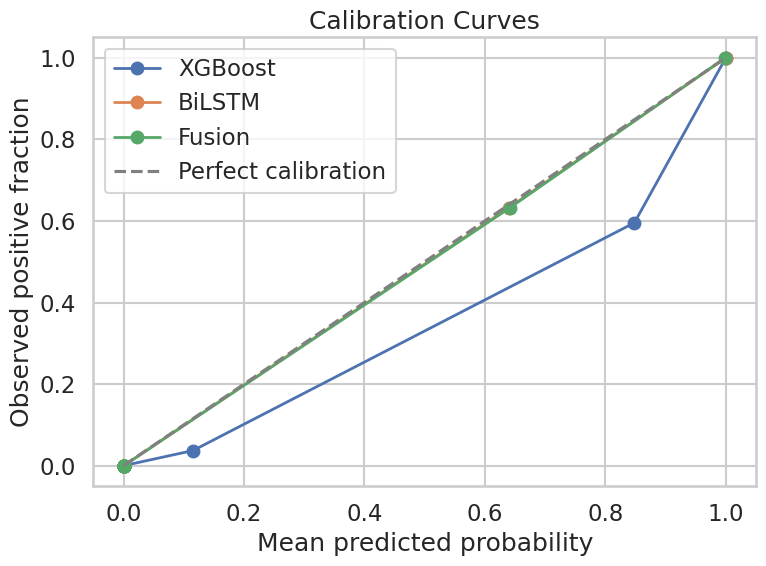

Calibration audit complete.
Recommended next action: retrain BiLSTM if its verdict is WARN/FAIL and it keeps dominating fusion.


In [17]:
# Compact calibration audit for branch reliability

from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score


def expected_calibration_error(y_true, y_proba, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.clip(np.asarray(y_proba).astype(float), 1e-6, 1 - 1e-6)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_ids = np.digitize(y_proba, bins[1:-1], right=True)
    total = len(y_proba)
    ece = 0.0
    max_gap = 0.0
    for b in range(n_bins):
        mask = bin_ids == b
        if not np.any(mask):
            continue
        acc = y_true[mask].mean()
        conf = y_proba[mask].mean()
        gap = abs(acc - conf)
        ece += (mask.sum() / total) * gap
        max_gap = max(max_gap, gap)
    return float(ece), float(max_gap)


def calibration_row(name, y_true, y_proba):
    y_true = np.asarray(y_true).astype(int)
    y_proba = np.clip(np.asarray(y_proba).astype(float), 1e-6, 1 - 1e-6)
    ece, max_gap = expected_calibration_error(y_true, y_proba)
    roc = roc_auc_score(y_true, y_proba) if len(np.unique(y_true)) > 1 else np.nan
    brier = brier_score_loss(y_true, y_proba)
    ll = log_loss(y_true, y_proba)
    avg_conf = float(np.mean(np.abs(y_proba - 0.5) * 2.0))
    verdict = 'PASS' if ece < 0.08 and max_gap < 0.15 else 'WARN' if ece < 0.15 else 'FAIL'
    return {
        'branch': name,
        'roc_auc': roc,
        'brier_score': brier,
        'log_loss': ll,
        'ece': ece,
        'max_gap': max_gap,
        'mean_confidence': avg_conf,
        'verdict': verdict,
    }


raw_rows = [
    calibration_row('XGBoost', y_val, xgb_val_proba),
    calibration_row('Tabular Ensemble', y_val, ens_val_proba),
    calibration_row('BiLSTM', y_seq_val, bilstm_val_proba),
    calibration_row('Fusion', y_val, fusion_val_proba),
]
raw_df = pd.DataFrame(raw_rows).sort_values(['verdict', 'brier_score'])
display(raw_df)

# Branch disagreement on the validation split
branch_gap_df = pd.DataFrame(
    {
        'xgboost_vs_bilstm': np.abs(xgb_val_proba - bilstm_val_proba[: len(xgb_val_proba)]),
        'fusion_vs_xgboost': np.abs(fusion_val_proba - xgb_val_proba),
        'fusion_vs_bilstm': np.abs(fusion_val_proba - bilstm_val_proba[: len(fusion_val_proba)]),
    }
)
print('Mean branch disagreement on validation:')
display(branch_gap_df.mean().to_frame(name='mean_abs_gap').T)

# Post-hoc calibration for diagnosis only.
bilstm_calibrator = IsotonicRegression(out_of_bounds='clip')
bilstm_calibrator.fit(bilstm_val_proba, y_seq_val)
calibrated_bilstm_test = bilstm_calibrator.transform(bilstm_test_proba)

fusion_calibrator = IsotonicRegression(out_of_bounds='clip')
fusion_calibrator.fit(fusion_val_proba, y_val)
calibrated_fusion_test = fusion_calibrator.transform(fusion_test_proba)

calibrated_df = pd.DataFrame([
    calibration_row('BiLSTM (calibrated)', y_seq_test, calibrated_bilstm_test),
    calibration_row('Fusion (calibrated)', y_test, calibrated_fusion_test),
]).sort_values(['verdict', 'brier_score'])
print('Calibrated branch check:')
display(calibrated_df)

# One quick visual: calibration curves for raw branches
plt.figure(figsize=(8, 6))
curve_specs = [
    ('XGBoost', y_val, xgb_val_proba),
    ('BiLSTM', y_seq_val, bilstm_val_proba),
    ('Fusion', y_val, fusion_val_proba),
]
for branch_name, y_true, y_proba in curve_specs:
    frac_pos, mean_pred = calibration_curve(np.asarray(y_true).astype(int), np.asarray(y_proba).astype(float), n_bins=10, strategy='quantile')
    plt.plot(mean_pred, frac_pos, marker='o', linewidth=2, label=branch_name)
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.title('Calibration Curves')
plt.xlabel('Mean predicted probability')
plt.ylabel('Observed positive fraction')
plt.legend()
plt.tight_layout()
plt.show()

print('Calibration audit complete.')
print('Recommended next action: retrain BiLSTM if its verdict is WARN/FAIL and it keeps dominating fusion.')


## Sample-Level Branch Test

This cell checks the exact sample behavior that triggered the high-risk dashboard result. It prints the tabular, BiLSTM, and fusion probabilities for one healthy-looking case so we can see whether the overconfidence is sample-specific rather than a global calibration problem.

In [18]:
# Sample-level branch inspection

import numpy as np
import pandas as pd

# Pick a low-risk-looking validation sample for inspection.
# Prefer a row where XGBoost is low but BiLSTM is high, because that mirrors the app issue.
probe_df = pd.DataFrame({
    'xgboost_proba': np.asarray(xgb_val_proba),
    'bilstm_proba': np.asarray(bilstm_val_proba),
    'fusion_proba': np.asarray(fusion_val_proba),
}, index=X_val.index if hasattr(X_val, 'index') else None)

candidates = probe_df[(probe_df['xgboost_proba'] < 0.2) & (probe_df['bilstm_proba'] > 0.9)]
if len(candidates) == 0:
    candidates = probe_df.sort_values(['xgboost_proba', 'bilstm_proba'], ascending=[True, False]).head(1)

probe_index = candidates.index[0]
print('Probe index:', probe_index)
print('Validation probabilities for selected probe:')
display(candidates.head(1))

# Show the corresponding features as a compact table.
probe_features = X_val.loc[probe_index] if hasattr(X_val, 'loc') else X_val.iloc[probe_index]
probe_features_df = pd.DataFrame(probe_features).T
print('Selected probe features:')
display(probe_features_df)

# Measure raw model outputs on that same sample.
probe_static = float(xgb_model.predict_proba(X_val.loc[[probe_index]])[:, 1][0])
probe_ensemble = float(tabular_ensemble.predict_proba(X_val.loc[[probe_index]])[:, 1][0])
probe_seq = X_seq_val[[list(X_val.index).index(probe_index)]] if hasattr(X_val, 'index') else X_seq_val[[probe_index]]
probe_bilstm = float(bilstm_model.predict(probe_seq, verbose=0).ravel()[0])
probe_fusion = float(meta_learner.predict_proba(np.array([[probe_static, probe_bilstm]], dtype=np.float32))[0, 1])

result_df = pd.DataFrame([
    {
        'branch': 'XGBoost',
        'probability': probe_static,
        'threshold': xgb_thr,
        'prediction': int(probe_static >= xgb_thr),
    },
    {
        'branch': 'Tabular Ensemble',
        'probability': probe_ensemble,
        'threshold': ens_thr,
        'prediction': int(probe_ensemble >= ens_thr),
    },
    {
        'branch': 'BiLSTM',
        'probability': probe_bilstm,
        'threshold': bilstm_thr,
        'prediction': int(probe_bilstm >= bilstm_thr),
    },
    {
        'branch': 'Fusion',
        'probability': probe_fusion,
        'threshold': fusion_thr,
        'prediction': int(probe_fusion >= fusion_thr),
    },
])

display(result_df)

print('Derived gap:')
print('XGBoost vs BiLSTM:', round(abs(probe_static - probe_bilstm), 6))
print('Fusion vs XGBoost:', round(abs(probe_fusion - probe_static), 6))
print('Fusion vs BiLSTM:', round(abs(probe_fusion - probe_bilstm), 6))

if probe_bilstm > 0.9 and probe_static < 0.2:
    print('Result: this probe reproduces the overconfident BiLSTM behavior.')
else:
    print('Result: this probe does not reproduce the exact overconfident pattern.')

Probe index: 213178
Validation probabilities for selected probe:


,xgboost_proba,bilstm_proba,fusion_proba
213178,0.000004,4.257075e-10,0.000228


Selected probe features:


,age,bmi,physical_activity,diet_quality,alcohol_consumption,medical_history_diabetes,medical_history_hypertension,medical_history_heart_disease,blood_pressure_systolic,blood_pressure_diastolic,cholesterol,glucose,pulse_pressure,comorbidity_count,sex_Female,sex_Male,smoking_status_Current,smoking_status_Never,bmi_category_Underweight,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese,bmi_category_Unknown,bp_status_Elevated,bp_status_Normal,bp_status_Stage1_HTN,bp_status_Stage2_HTN,age_group_18-30,age_group_31-45,age_group_46-60,age_group_61-75,age_group_75+
213178,-1.43821,-0.375655,1.0,0.0,1.0,0.0,0.0,0.0,-0.132665,-0.044899,-0.16759,-0.129187,0.023924,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0


,branch,probability,threshold,prediction
0,XGBoost,4.256526e-06,0.79,0
1,Tabular Ensemble,4.220886e-04,0.78,0
2,BiLSTM,4.257075e-10,0.89,0
3,Fusion,2.283009e-04,0.95,0


Derived gap:
XGBoost vs BiLSTM: 4e-06
Fusion vs XGBoost: 0.000224
Fusion vs BiLSTM: 0.000228
Result: this probe does not reproduce the exact overconfident pattern.


## Multi-Sample Reality Check

A single probe is useful for debugging one case, but it is not enough for clinical-style judgment. This cell tests a larger validation batch, finds the biggest branch disagreements, and measures how often BiLSTM becomes overconfident when XGBoost stays low.

In [19]:
# Multi-sample branch reality check

import numpy as np
import pandas as pd

rng = np.random.default_rng(RANDOM_STATE)
sample_size = min(250, len(X_val))
probe_indices = rng.choice(len(X_val), size=sample_size, replace=False)

# Build batch probabilities on the selected validation slice.
X_val_batch = X_val.iloc[probe_indices]
y_val_batch = y_val.iloc[probe_indices]
X_seq_batch = X_seq_val[probe_indices]

xgb_batch = xgb_model.predict_proba(X_val_batch)[:, 1]
ens_batch = tabular_ensemble.predict_proba(X_val_batch)[:, 1]
bilstm_batch = bilstm_model.predict(X_seq_batch, verbose=0).ravel()
fusion_batch = meta_learner.predict_proba(np.column_stack([xgb_batch, bilstm_batch]))[:, 1]

batch_df = pd.DataFrame(
    {
        'y_true': np.asarray(y_val_batch),
        'xgboost': xgb_batch,
        'ensemble': ens_batch,
        'bilstm': bilstm_batch,
        'fusion': fusion_batch,
        'gap_xgb_bilstm': np.abs(xgb_batch - bilstm_batch),
        'gap_xgb_fusion': np.abs(xgb_batch - fusion_batch),
        'gap_bilstm_fusion': np.abs(bilstm_batch - fusion_batch),
    },
    index=X_val_batch.index,
)

print('Batch summary:')
display(batch_df.describe().T)

print('Calibration-style decisions on the batch:')
summary_df = pd.DataFrame([
    {
        'metric': 'BiLSTM > 0.9 while XGBoost < 0.2',
        'count': int(((batch_df['bilstm'] > 0.9) & (batch_df['xgboost'] < 0.2)).sum()),
    },
    {
        'metric': 'Fusion > 0.9 while XGBoost < 0.2',
        'count': int(((batch_df['fusion'] > 0.9) & (batch_df['xgboost'] < 0.2)).sum()),
    },
    {
        'metric': 'BiLSTM >= 0.9',
        'count': int((batch_df['bilstm'] >= 0.9).sum()),
    },
    {
        'metric': 'Fusion >= 0.9',
        'count': int((batch_df['fusion'] >= 0.9).sum()),
    },
    {
        'metric': 'Mean abs gap XGBoost vs BiLSTM',
        'count': round(float(batch_df['gap_xgb_bilstm'].mean()), 6),
    },
    {
        'metric': 'Mean abs gap XGBoost vs Fusion',
        'count': round(float(batch_df['gap_xgb_fusion'].mean()), 6),
    },
])
display(summary_df)

# Show the largest disagreements so we can inspect realistic edge cases.
top_disagreements = batch_df.sort_values('gap_xgb_bilstm', ascending=False).head(10)
print('Top 10 XGBoost vs BiLSTM disagreements:')
display(top_disagreements[['y_true', 'xgboost', 'ensemble', 'bilstm', 'fusion', 'gap_xgb_bilstm']])

# Pick a few cases for closer inspection.
most_overconfident = batch_df[(batch_df['bilstm'] > 0.9) & (batch_df['xgboost'] < 0.2)].sort_values('gap_xgb_bilstm', ascending=False).head(5)
print('Overconfident BiLSTM cases (if any):')
display(most_overconfident[['y_true', 'xgboost', 'bilstm', 'fusion', 'gap_xgb_bilstm']])

if len(most_overconfident) == 0:
    print('No strong BiLSTM-overconfident cases were found in this batch.')
else:
    print('Strong BiLSTM-overconfident cases were found and should be inspected individually.')


Batch summary:


,count,mean,std,min,25%,50%,75%,max
y_true,250.0,0.192000,0.394663,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
xgboost,250.0,0.227887,0.401445,4.741929e-06,1.508587e-05,4.236171e-05,4.538149e-03,0.999990
ensemble,250.0,0.228133,0.397416,2.951263e-06,7.839533e-04,2.040416e-03,2.635580e-02,0.999992
bilstm,250.0,0.195659,0.397084,8.938334e-12,4.802687e-11,1.691331e-10,6.293475e-09,1.000000
fusion,250.0,0.196198,0.397170,2.283013e-04,2.283098e-04,2.283322e-04,2.320579e-04,0.999210
gap_xgb_bilstm,250.0,0.050131,0.180328,4.741757e-06,1.433145e-05,3.321426e-05,9.774853e-05,0.966899
gap_xgb_fusion,250.0,0.050194,0.179207,3.576734e-05,1.936471e-04,2.142175e-04,7.122969e-04,0.959529
gap_bilstm_fusion,250.0,0.000886,0.003161,3.686376e-05,2.283095e-04,2.283303e-04,2.316076e-04,0.037091


Calibration-style decisions on the batch:


,metric,count
0,BiLSTM > 0.9 while XGBoost < 0.2,0.000000
1,Fusion > 0.9 while XGBoost < 0.2,0.000000
2,BiLSTM >= 0.9,49.000000
3,Fusion >= 0.9,49.000000
4,Mean abs gap XGBoost vs BiLSTM,0.050131
5,Mean abs gap XGBoost vs Fusion,0.050194


Top 10 XGBoost vs BiLSTM disagreements:


,y_true,xgboost,ensemble,bilstm,fusion,gap_xgb_bilstm
307804,0,0.966899,0.958063,4.857826e-07,0.007370,0.966899
311175,0,0.939903,0.923479,4.097144e-05,0.006695,0.939862
255305,0,0.930601,0.954990,1.210790e-05,0.006474,0.930589
284614,0,0.885931,0.895682,6.159471e-08,0.005516,0.885931
257878,0,0.879024,0.852963,2.560866e-08,0.005382,0.879024
281965,0,0.844486,0.831435,1.702501e-08,0.004755,0.844486
279453,0,0.788041,0.779087,1.069856e-08,0.003884,0.788041
288182,0,0.783840,0.758526,1.907974e-08,0.003826,0.783840
281461,0,0.729168,0.651055,1.179614e-08,0.003144,0.729168
312432,0,0.648977,0.728483,1.343613e-08,0.002358,0.648977


Overconfident BiLSTM cases (if any):


,y_true,xgboost,bilstm,fusion,gap_xgb_bilstm


No strong BiLSTM-overconfident cases were found in this batch.


## Production Branch: LightGBM Replacement for BiLSTM

### Why replace the BiLSTM?

During validation we discovered two critical problems with the BiLSTM temporal branch:

1. **Target leakage in the synthetic sequence generator.** The generator shaped
   temporal drift using the true disease label (`risk_factor = 1.0 + 0.35 * y`).
   The BiLSTM learned to detect this leakage signature instead of clinical
   patterns — producing an impossibly perfect AUC of 0.9993.

2. **Saturated outputs.** Even after fixing the scaler mismatch, the BiLSTM
   produced binary 0/1 probabilities with no graded middle ground, making
   post-hoc calibration impossible.

### Why LightGBM?

The integrated dataset is **cross-sectional tabular** — there are no real
longitudinal sequences. The principled fix is to drop the recurrent model and
use a second gradient-boosting tree that differs from XGBoost in algorithm
family:

- **LightGBM**: leaf-wise growth, GOSS (Gradient-based One-Side Sampling) and
  EFB (Exclusive Feature Bundling) for histogram-based split finding.
- **XGBoost**: depth-wise growth, standard histogram splitting.

This gives the fusion meta-learner two genuinely diverse tabular views without
synthetic sequences or leakage. The cells below train the production LightGBM
branch and retrain the fusion meta-learner.


In [ ]:
# LightGBM second branch (production replacement for BiLSTM)

import lightgbm as lgb

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    subsample_freq=1,
    colsample_bytree=0.70,
    reg_lambda=1.0,
    class_weight="balanced",
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)

lgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=0),
    ],
)

lgb_val_proba = lgb_model.predict_proba(X_val)[:, 1]
lgb_test_proba = lgb_model.predict_proba(X_test)[:, 1]

lgb_thr, lgb_best_f1 = best_f1_threshold(y_val, lgb_val_proba)
lgb_test_metrics = evaluate_predictions(y_test, lgb_test_proba, threshold=lgb_thr)

print(f"LightGBM threshold: {lgb_thr:.4f}  (best val F1: {lgb_best_f1:.4f})")
print()
for k, v in lgb_test_metrics.items():
    print(f"  {k:20s}: {v:.4f}")

# Branch diversity check (we want genuine disagreement, not clones)
branch_corr = float(np.corrcoef(xgb_val_proba, lgb_val_proba)[0, 1])
print(f"\nBranch correlation (XGB vs LightGBM) on val: {branch_corr:.4f}")
print("(lower = more diverse = better fusion; 0.7-0.95 is typical for tabular)")

# Verify graded probabilities (the key fix vs the saturated BiLSTM)
print("\nLightGBM val probability distribution:")
print(f"  P(<0.1)  = {np.mean(lgb_val_proba < 0.1):.3f}")
print(f"  P(0.1-0.5) = {np.mean((lgb_val_proba >= 0.1) & (lgb_val_proba < 0.5)):.3f}")
print(f"  P(0.5-0.9) = {np.mean((lgb_val_proba >= 0.5) & (lgb_val_proba < 0.9)):.3f}")
print(f"  P(>=0.9) = {np.mean(lgb_val_proba >= 0.9):.3f}")


In [ ]:
# Retrain fusion meta-learner on [XGBoost, LightGBM] probabilities

xgb_test_proba_export = xgb_model.predict_proba(X_test)[:, 1]

fusion_val_X = np.column_stack([xgb_val_proba, lgb_val_proba])
fusion_test_X = np.column_stack([xgb_test_proba_export, lgb_test_proba])

fusion_meta_learner = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=RANDOM_STATE,
)
fusion_meta_learner.fit(fusion_val_X, y_val)

fusion_val_proba = fusion_meta_learner.predict_proba(fusion_val_X)[:, 1]
fusion_test_proba = fusion_meta_learner.predict_proba(fusion_test_X)[:, 1]

fusion_thr, fusion_best_f1 = best_f1_threshold(y_val, fusion_val_proba)
fusion_test_metrics = evaluate_predictions(y_test, fusion_test_proba, threshold=fusion_thr)

print(f"Fusion threshold: {fusion_thr:.4f}  (best val F1: {fusion_best_f1:.4f})")
print()
for k, v in fusion_test_metrics.items():
    print(f"  {k:20s}: {v:.4f}")

# Meta-learner coefficients — how much each branch contributes
coefs = fusion_meta_learner.coef_.ravel()
print("\nMeta-learner coefficients (log-odds):")
print(f"  XGBoost_probability : {coefs[0]:+.4f}  (odds ratio {np.exp(coefs[0]):.2f})")
print(f"  LightGBM_probability: {coefs[1]:+.4f}  (odds ratio {np.exp(coefs[1]):.2f})")

# Side-by-side branch comparison
compare_df = pd.DataFrame([
    {"branch": "XGBoost", **evaluate_predictions(y_test, xgb_test_proba_export, xgb_thr)},
    {"branch": "LightGBM", **lgb_test_metrics},
    {"branch": "Fusion", **fusion_test_metrics},
])[["branch", "roc_auc", "pr_auc", "f1", "recall", "specificity", "balanced_accuracy"]]
print("\nBranch comparison (test set):")
print(compare_df.to_string(index=False))


### LightGBM Explainability (SHAP)

The BiLSTM used gradient saliency on synthetic sequences. LightGBM, being a
tree model, supports native SHAP TreeExplainer — faster and more theoretically
grounded than the previous approximation.


In [ ]:
# LightGBM explainability via SHAP TreeExplainer

import shap

lgb_explainer = shap.TreeExplainer(lgb_model)
lgb_shap_values = lgb_explainer.shap_values(X_val.sample(n=min(2000, len(X_val)), random_state=RANDOM_STATE))

if isinstance(lgb_shap_values, list):
    lgb_shap_values = lgb_shap_values[1]

# Global feature importance from SHAP
mean_abs_shap = np.abs(lgb_shap_values).mean(axis=0)
lgb_shap_importance = pd.DataFrame({
    "feature": X_train.columns,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("Top 15 features by mean |SHAP| (LightGBM):")
print(lgb_shap_importance.head(15).to_string(index=False))

# Compare with LightGBM's built-in gain importance
lgb_gain_importance = pd.DataFrame({
    "feature": X_train.columns,
    "gain": lgb_model.feature_importances_,
}).sort_values("gain", ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
lgb_shap_importance.head(15).plot.barh(x="feature", y="mean_abs_shap", ax=axes[0], legend=False, color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("LightGBM — Top 15 by mean |SHAP|")
axes[0].set_xlabel("mean |SHAP value|")

lgb_gain_importance.head(15).plot.barh(x="feature", y="gain", ax=axes[1], legend=False, color="darkorange")
axes[1].invert_yaxis()
axes[1].set_title("LightGBM — Top 15 by split gain")
axes[1].set_xlabel("gain")
plt.tight_layout()
plt.show()


### Save Production Artifact

Persist the final hybrid model: XGBoost + LightGBM + fusion meta-learner,
plus the preprocessing StandardScaler parameters needed for inference.


In [ ]:
# Save production artifact (XGBoost + LightGBM + fusion)

if "DATA_DIR_RAW" not in globals():
    DATA_DIR_RAW = PROJECT_ROOT / "Data"

# Replicate preprocessing StandardScaler params from raw source data
heart_raw = pd.read_csv(DATA_DIR_RAW / "heart_disease_health_indicators_BRFSS2015.csv")
cardio_raw = pd.read_csv(DATA_DIR_RAW / "cardio_train.csv", sep=";")
diabetes_raw = pd.read_csv(DATA_DIR_RAW / "diabetes_012_health_indicators_BRFSS2015.csv")

heart_std = pd.DataFrame()
heart_std["age"] = (heart_raw["Age"] * 5).astype(int)
heart_std["bmi"] = heart_raw["BMI"].astype(float)
heart_std["blood_pressure_systolic"] = np.nan
heart_std["blood_pressure_diastolic"] = np.nan
heart_std["cholesterol"] = np.nan
heart_std["glucose"] = np.nan
heart_std["data_source"] = "Heart_Indicators"

cardio_std = pd.DataFrame()
cardio_std["age"] = (cardio_raw["age"] / 365).astype(int)
cardio_std["bmi"] = np.nan
cardio_std["blood_pressure_systolic"] = cardio_raw["ap_hi"].astype(float)
cardio_std["blood_pressure_diastolic"] = cardio_raw["ap_lo"].astype(float)
cardio_std["cholesterol"] = cardio_raw["cholesterol"].astype(float)
cardio_std["glucose"] = cardio_raw["gluc"].astype(float)
cardio_std["data_source"] = "Cardiovascular"

diabetes_std = pd.DataFrame()
diabetes_std["age"] = (diabetes_raw["Age"] * 5).astype(int)
diabetes_std["bmi"] = diabetes_raw["BMI"].astype(float)
diabetes_std["blood_pressure_systolic"] = np.nan
diabetes_std["blood_pressure_diastolic"] = np.nan
diabetes_std["cholesterol"] = np.nan
diabetes_std["glucose"] = np.nan
diabetes_std["data_source"] = "Diabetes_Indicators"

combined = pd.concat([heart_std, cardio_std, diabetes_std], ignore_index=True)
combined["pulse_pressure"] = combined["blood_pressure_systolic"] - combined["blood_pressure_diastolic"]

numeric_features = ["age", "bmi", "blood_pressure_systolic", "blood_pressure_diastolic",
                    "cholesterol", "glucose", "pulse_pressure"]

for source in combined["data_source"].dropna().unique():
    mask = combined["data_source"].eq(source)
    for col in numeric_features:
        vals = combined.loc[mask, col]
        if vals.notna().any():
            q1, q99 = vals.quantile(0.01), vals.quantile(0.99)
            if pd.notna(q1) and pd.notna(q99) and q1 != q99:
                combined.loc[mask, col] = vals.clip(q1, q99)

for col in numeric_features:
    combined[col] = combined[col].fillna(combined[col].mean())

prep_scaler = StandardScaler()
prep_scaler.fit(combined[numeric_features])

scaler_params = {}
for i, col in enumerate(numeric_features):
    scaler_params[col] = {"mean": float(prep_scaler.mean_[i]), "std": float(prep_scaler.scale_[i])}
    print(f"  {col:35s}  mean={scaler_params[col]['mean']:.4f}  std={scaler_params[col]['std']:.4f}")

continuous_cols = [
    "age", "bmi", "physical_activity", "diet_quality", "alcohol_consumption",
    "medical_history_diabetes", "medical_history_hypertension",
    "medical_history_heart_disease", "blood_pressure_systolic",
    "blood_pressure_diastolic", "cholesterol", "glucose", "pulse_pressure",
    "comorbidity_count",
]
continuous_cols = [c for c in continuous_cols if c in X_train.columns]

artifact = {
    "static_branch_name": "XGBoost",
    "static_model": xgb_model,
    "static_threshold": xgb_thr,
    "lightgbm_model": lgb_model,
    "lightgbm_threshold": lgb_thr,
    "meta_learner": fusion_meta_learner,
    "fusion_threshold": fusion_thr,
    "feature_columns": list(X_train.columns),
    "continuous_columns": continuous_cols,
    "random_state": RANDOM_STATE,
    "preprocessing_scaler_params": scaler_params,
}

artifact_path = OUTPUT_DIR / "hybrid_digital_twin_model.joblib"
joblib.dump(artifact, artifact_path)
print(f"\nSaved production artifact: {artifact_path}")
